In [2]:
import torch
import torchvision
from torchvision import transforms
from torch import nn, optim
from torch.utils.data import DataLoader, random_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## These are the residual blocks, which involve skip conenctions and dimension matching using projection shortcuts

In [3]:
class ResBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(num_features=out_channels)
    self.relu = nn.ReLU()
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(num_features=out_channels)
    self.projector = nn.Identity()

    if (stride != 1 or in_channels != out_channels):
      # Projector in case the w/h is not the same or channel no. is not the same
      # I saw that as long as stride is same, with offsetted padding of any kernel size the dimensions are the same
      # ((a - k + 2p) / s) + 1 is the formula I referred
      self.projector = nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channels)
      )

  def forward(self, x):
    identity = self.projector(x)
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)
    x += identity
    return self.relu(x)

## This is the actual modified Resnet-18 network

In [ ]:
class HouseResNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn = nn.BatchNorm2d(num_features=64)
    self.relu = nn.ReLU()

    channels = [64, 64, 128, 128, 256, 256, 512, 512]
    prev_channel = 64
    thic_layers = []

    for n, channel in enumerate(channels):
      # More channels means I downsample to preserve resources and make performance better
      stride = 2 if prev_channel != channel else 1
      thic_layers.append(ResBlock(in_channels=prev_channel, out_channels=channel, stride=stride))
      prev_channel = channel

    self.res_layers = nn.Sequential(*thic_layers)
    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(in_features=512, out_features=10)
    self.flatten = nn.Flatten()

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn(x)
    x = self.relu(x)
    x = self.res_layers(x)
    x = self.avgpool(x)
    x = self.flatten(x)
    x= self.fc(x)
    # No softmax as CrossEntropyLoss is used, which takes care of it
    return x


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transform)

train_length = int(len(full_dataset) * 0.85)
val_length = len(full_dataset) - train_length

train_dataset, val_dataset = random_split(full_dataset, [train_length, val_length])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 182M/182M [00:17<00:00, 10.3MB/s]
100%|██████████| 64.3M/64.3M [00:12<00:00, 4.98MB/s]


In [10]:
epochs = 5
model = HouseResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
train_losses = []
validation_losses = []
raw_train_losses = []
raw_validation_losses = []
train_accuracy = []
validation_accuracy = []

for e in range(epochs):
  model.train()

  running_train_loss = 0
  no_train_correct = 0
  total_train = 0

  for n, (X, y) in enumerate(train_loader):
    X = X.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()

    running_train_loss += loss.item()

    _, predicted = torch.max(y_pred, 1)
    total_train += len(y)
    no_train_correct += (predicted == y).sum().item()

    raw_train_losses.append(loss.item())

  avg_train_loss = running_train_loss / len(train_loader)
  train_losses.append(avg_train_loss)
  train_accuracy.append(no_train_correct / total_train)

  model.eval()

  running_val_loss = 0
  no_val_correct = 0
  total_val = 0

  with torch.no_grad():
    for n, (X, y) in enumerate(val_loader):
      X = X.to(device)
      y = y.to(device)

      y_pred = model(X)
      # Here loss is loss averaged amongst all images in that bacth
      loss = criterion(y_pred, y)

      running_val_loss += loss.item()

      _, predicted = torch.max(y_pred, 1)
      total_val += len(y)
      no_val_correct += (predicted == y).sum().item()

      raw_validation_losses.append(loss.item())

  avg_val_loss = running_val_loss / len(val_loader)
  validation_losses.append(avg_val_loss)
  validation_accuracy.append(no_val_correct / total_val)

  print(f'Epoch {e+1}/{epochs} | ' f'Train Loss: {avg_train_loss:.4f} | Train Acc: {(train_accuracy[-1]* 100):.2f}% | ' f'Val Loss: {avg_val_loss:.4f} | Val Acc: {(validation_accuracy[-1] * 100):.2f}%')

Epoch 1/5 | Train Loss: 0.8098 | Train Acc: 73.18% | Val Loss: 0.3188 | Val Acc: 90.44%
Epoch 2/5 | Train Loss: 0.2824 | Train Acc: 91.71% | Val Loss: 0.3219 | Val Acc: 90.15%
Epoch 3/5 | Train Loss: 0.2256 | Train Acc: 93.39% | Val Loss: 0.2322 | Val Acc: 93.35%
Epoch 4/5 | Train Loss: 0.1919 | Train Acc: 94.37% | Val Loss: 0.2323 | Val Acc: 93.43%
Epoch 5/5 | Train Loss: 0.1610 | Train Acc: 95.33% | Val Loss: 0.2117 | Val Acc: 94.04%


In [12]:
running_test_loss = 0
no_test_correct = 0
total_test = 0
testing_losses = []
testing_accuracy = 0

with torch.no_grad():
  for n, (X, y) in enumerate(test_loader):
    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    loss = criterion(y_pred, y)

    running_test_loss += loss.item()

    _, predicted = torch.max(y_pred, 1)
    total_test += len(y)
    no_test_correct += (predicted == y).sum().item()
    testing_losses.append(loss.item())

avg_test_loss = running_test_loss / len(test_loader)
testing_accuracy = no_test_correct / total_test

print(f'Test Loss: {avg_test_loss:.4f} |' f'Test Acc: {(testing_accuracy * 100):.2f}%')

Test Loss: 0.2054 |Test Acc: 94.35%


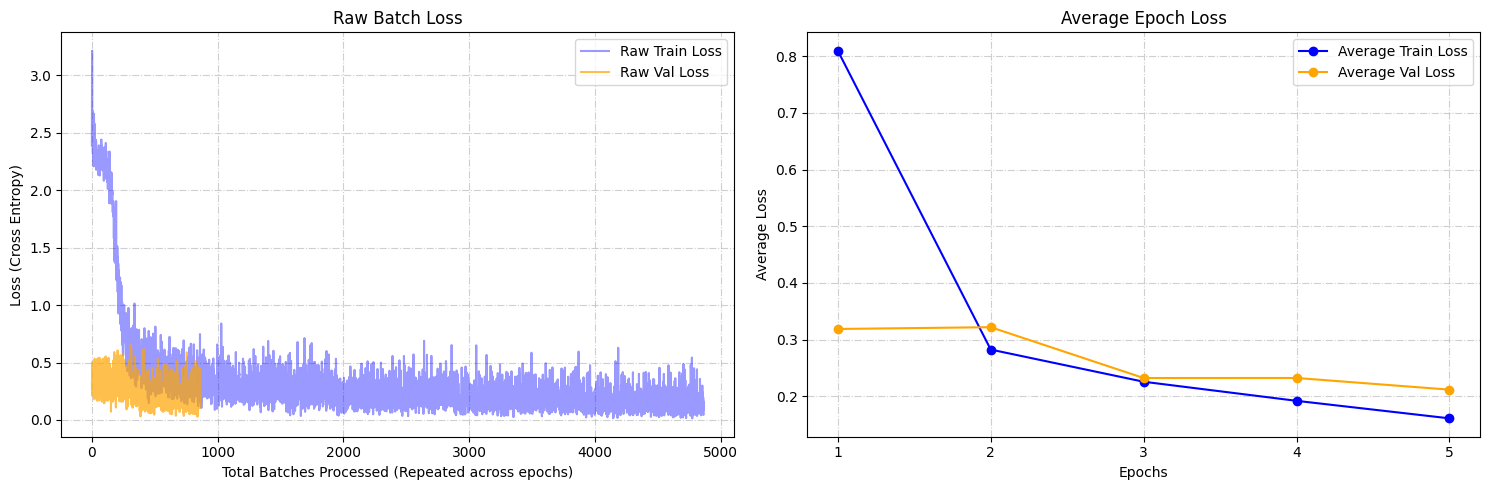

In [28]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(raw_train_losses, label='Raw Train Loss', color='blue', alpha=0.4)
ax1.plot(raw_validation_losses, label='Raw Val Loss', color='orange', alpha=0.7)

ax1.set_title("Raw Batch Loss")
ax1.set_xlabel("Total Batches Processed (Repeated across epochs)")
ax1.set_ylabel("Loss (Cross Entropy)")
ax1.legend()
ax1.grid(True, linestyle='-.', alpha=0.6)

epochs_range = range(1, epochs + 1)

ax2.plot(epochs_range, train_losses, label='Average Train Loss', color='blue', marker='o', linewidth=1.5)
ax2.plot(epochs_range, validation_losses, label='Average Val Loss', color='orange', marker='o', linewidth=1.5)

ax2.set_title("Average Epoch Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Average Loss")
ax2.set_xticks(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='-.', alpha=0.6)

plt.tight_layout()
plt.show()

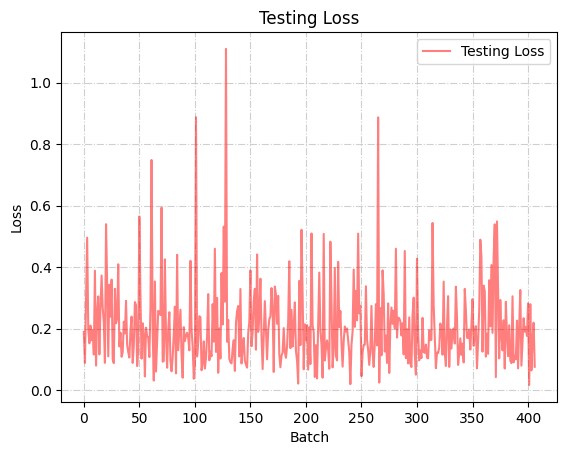

In [27]:
plt.plot(testing_losses, color='red', label='Testing Loss', alpha=0.5)
plt.legend()
plt.title('Testing Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.grid(True, linestyle='-.', alpha=0.6)
plt.show()